#### **Table of Contents**

**Data Preparation**

1. [Load Dataset](#load-dataset)
2. [Feature Classification](#feature-classification)
3. [Train/ CV/ Test Split](#train-test-split)

**Data Preprocessing**

4. [Missing Value Treatment](#missing-value-treatment)
5. [Outlier Treatment](#outlier-treatment)
6. [Skewness Transformation](#skewness-transformation)
7. [Feature Engineering](#feature-engineering)
8. [Feature Encoding](#feature-encoding)
9. [Feature Scaling](#feature-scaling)
10. [Data Validation](#data-validation)

**Feature Optimization**

11. [Multicollinearity Treatment](#multicollinearity-treatment)
12. [Feature Selection](#feature-selection)
13. [Dimensionality Reduction (PCA)](#dimensionality-reduction-pca)

**Deployment Preparation**

14. [Preprocessing Pipeline](#preprocessing-pipeline)

**Conclusion**

15. [Summary](#summary)

### **1. Load Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


df = pd.read_csv("AmesHousing_cleaned.csv")
df.shape

(2930, 82)

### 2.  **Feature classification**

###  Numerical Features <a name="num-features"></a>

In [2]:
numerical_features = [
    "Lot Frontage", "Lot Area", "Mas Vnr Area",
    "BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF", "Total Bsmt SF",
    "1st Flr SF", "2nd Flr SF", "Low Qual Fin SF", "Gr Liv Area",
    "Garage Area", "Garage Cars",
    "Wood Deck SF", "Open Porch SF", "Enclosed Porch", "3Ssn Porch",
    "Screen Porch", "Pool Area", "Misc Val",
    "Bsmt Full Bath", "Bsmt Half Bath", "Full Bath", "Half Bath",
    "Bedroom AbvGr", "Kitchen AbvGr", "TotRms AbvGrd", "Fireplaces",
]

print(f"{len(numerical_features)} numerical features")

28 numerical features


### Nominal Categorical Features <a name="nominal-features"></a>

No inherent order — these will need one-hot / dummy encoding, not a
single integer column.

In [3]:
nominal_features = [
    "MS SubClass",       # see 10.5 — stored as int, but not a quantity
    "MS Zoning", "Street", "Alley", "Land Contour", "Lot Config",
    "Neighborhood", "Condition 1", "Condition 2", "Bldg Type", "House Style",
    "Roof Style", "Roof Matl", "Exterior 1st", "Exterior 2nd", "Mas Vnr Type",
    "Foundation", "Heating", "Central Air", "Electrical", "Garage Type",
    "Misc Feature", "Sale Type", "Sale Condition",
]

print(f"{len(nominal_features)} nominal categorical features")

24 nominal categorical features


### Ordinal Categorical Features <a name="ordinal-features"></a>

Each of these has a real, defensible rank. `Overall Qual` and `Overall Cond`
are already stored as integers 1–10 by the data provider, so no mapping is
needed for them — they're included here for completeness since they *are*
ordinal, just pre-encoded. The rest are text categories, so the rank order
each one should map to is recorded now (mapping applied in the next
notebook) rather than left implicit.

Note that several of these orderings start from the sentinel values created
in Section 5 (`"No Basement"`, `"NA"`, `"No Fireplace"`, `"No Fence"`) — those
sentinels represent the complete absence of the feature, which is naturally
the bottom of the quality scale, not a missing value to drop.

In [4]:
ordinal_features = [
    "Lot Shape", "Utilities", "Land Slope",
    "Overall Qual", "Overall Cond",
    "Exter Qual", "Exter Cond",
    "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2",
    "Heating QC", "Kitchen Qual", "Functional", "Fireplace Qu",
    "Garage Finish", "Garage Qual", "Garage Cond",
    "Paved Drive", "Fence", "Pool QC",
]

# Rank order, worst/least to best/most. Only text-valued columns need an
# explicit mapping — Overall Qual / Overall Cond are already numeric.
ordinal_rank_order = {
    "Lot Shape": ["IR3", "IR2", "IR1", "Reg"],
    "Utilities": ["ELO", "NoSeWa", "NoSewr", "AllPub"],
    "Land Slope": ["Sev", "Mod", "Gtl"],
    "Exter Qual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Exter Cond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt Qual": ["No Basement", "Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt Cond": ["No Basement", "Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt Exposure": ["No Basement", "No", "Mn", "Av", "Gd"],
    "BsmtFin Type 1": ["No Basement", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFin Type 2": ["No Basement", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "Heating QC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Kitchen Qual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "Fireplace Qu": ["No Fireplace", "Po", "Fa", "TA", "Gd", "Ex"],
    "Garage Finish": ["NA", "Unf", "RFn", "Fin"],
    "Garage Qual": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "Garage Cond": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "Paved Drive": ["N", "P", "Y"],
    "Fence": ["No Fence", "MnWw", "GdWo", "MnPrv", "GdPrv"],
    "Pool QC": ["No Pool", "Fa", "TA", "Gd", "Ex"],
}

print(f"{len(ordinal_features)} ordinal categorical features "
      f"({len(ordinal_rank_order)} with an explicit text-to-rank mapping)")

22 ordinal categorical features (20 with an explicit text-to-rank mapping)


### Time-Related Features <a name="time-features"></a>

Kept separate from ordinary numerical features on purpose — see the
explanation above. No transformation happens here yet; this is a marker for
the feature-engineering notebook to derive things like property age at sale
(`Yr Sold - Year Built`) and years since remodel, rather than scaling raw
year values as if they were just another measurement.

In [5]:
time_features = [
    "Year Built", "Year Remod/Add", "Garage Yr Blt", "Mo Sold", "Yr Sold",
]

print(f"{len(time_features)} time-related features")

5 time-related features


###  Why `MS SubClass` Is Categorical, Not Numerical <a name="ms-subclass"></a>

`MS SubClass` is stored as an integer (`20`, `30`, `45`, `60`, ... `190`),
which makes it easy to mistake for a numerical feature — but the numbers are
**codes**, not quantities:

- Each code represents a specific *combination* of dwelling type, number of
  stories, and age bracket (e.g. `60` = 2-Story, 1946 & Newer; `90` = Duplex,
  all styles and ages). Two codes have no meaningful arithmetic relationship
  — `60 - 20` isn't "40 more house," and there's no sense in which `160`
  (2-Story PUD) is "worth more" than `90` (Duplex) simply because it's a
  bigger number.
- The codes aren't even consistently ordered by any single underlying
  property. `90` (Duplex) sits numerically between `85` (Split Foyer) and
  `120` (1-Story PUD) — three unrelated categories with no shared scale.
- If left as an integer, a model (or a naive `StandardScaler`) would treat
  `MS SubClass` as continuous and learn a spurious linear relationship with
  price based on code magnitude, and a correlation matrix would report a
  "correlation" that means nothing.

For these reasons `MS SubClass` is classified as **nominal**, not numerical,
and will be cast to a string/`category` dtype and one-hot encoded like any
other nominal feature, despite pandas loading it as `int64`.

In [6]:
df["MS SubClass"] = df["MS SubClass"].astype(str)
print(df["MS SubClass"].dtype)
print(df["MS SubClass"].unique())

object
['20' '60' '120' '50' '85' '160' '80' '30' '90' '190' '45' '70' '75' '40'
 '180' '150']


### Completeness Check <a name="completeness-check"></a>

Every column in the cleaned dataframe should land in exactly one group:
numerical, nominal, ordinal, time-related, an identifier, or the target.
This check catches two easy mistakes — a column left unclassified, and a
column accidentally classified twice.

In [7]:
identifier_features = [col for col in ["Order", "PID"] if col in df.columns]
target_feature = ["SalePrice"] if "SalePrice" in df.columns else []

all_grouped = (
    numerical_features
    + nominal_features
    + ordinal_features
    + time_features
    + identifier_features
    + target_feature
)

duplicates = {col for col in all_grouped if all_grouped.count(col) > 1}
unclassified = set(df.columns) - set(all_grouped)
unknown = set(all_grouped) - set(df.columns)

print(f"Total columns classified: {len(all_grouped)}")
print(f"Total columns in dataframe: {df.shape[1]}")

if duplicates:
    print(f" Columns classified more than once: {duplicates}")
if unclassified:
    print(f" Columns not yet classified: {unclassified}")
if unknown:
    print(f" Classified names not found in dataframe (typo?): {unknown}")
if not duplicates and not unclassified and not unknown:
    print(" Every column is classified exactly once.")

Total columns classified: 82
Total columns in dataframe: 82
 Every column is classified exactly once.


## 3. Train/Test Split <a name="train-test-split"></a>

Before any preprocessing is performed, the cleaned dataset is divided into training and testing subsets. Every preprocessing step from this point on -- imputation, outlier removal, encoding categories, scaling -- is **learned exclusively from the training data** and then applied unchanged to the test data. This prevents **data leakage**, so the final test-set evaluation reflects performance on genuinely unseen data.

**Cross-validation note:** this notebook produces a two-way split (`train` / `test`), not a static third `cv` partition. Model selection and hyperparameter tuning (Notebook 4) will use **K-Fold cross-validation on the training set** (`sklearn.model_selection.KFold` / `cross_val_score`) -- so "CV" here is a resampling procedure applied within `X_train`, not a fixed held-out DataFrame. The held-out `test` set stays untouched until final model evaluation.

In [8]:
from sklearn.model_selection import train_test_split

# Separate predictors and target
X = df.drop(columns="SalePrice")
y = df["SalePrice"]

# Train/Test split. K-Fold CV (Notebook 4) will resample within X_train --
# no separate static CV partition is created here.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

# Reset indices so every later positional/index-based operation (e.g. .loc
# masks built from (X_train) lines up cleanly between X_train/y_train and between X_test/y_test.
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Training features: {X_train.shape[1]}")
print(f"Testing features : {X_test.shape[1]}")

Training samples : 2344
Testing samples  : 586
Training features: 81
Testing features : 81


## 4. Missing Value Treatment <a name="missing-value-treatment"></a>

EDA Section 2 already resolved every missing value in the source data before this notebook's input file (`AmesHousing_cleaned.csv`) was written: structural `NaN`s (absence of a feature) became explicit categories such as `"No Garage"` / `"No Basement"`, and `Lot Frontage` was imputed by neighborhood median. This step is therefore a **verification**, not new imputation -- confirming that split-induced row subsetting didn't reintroduce nulls, and that no missing-value handling is owed here.

In [9]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test :", X_test.isnull().sum().sum())
print("Missing values in y_train:", y_train.isnull().sum())
print("Missing values in y_test :", y_test.isnull().sum())

Missing values in X_train: 0
Missing values in X_test : 0
Missing values in y_train: 0
Missing values in y_test : 0


## 5. Outlier Treatment <a name="outlier-treatment"></a>

| Question | Finding | Action |
|---|---|---|
| Genuine data-quality errors? | One `Garage Yr Blt` typo (2207 → 2007); a few `Partial`-sale date orderings explained by contract-before-completion timing | **Corrected** above; no removal needed |
| Are extreme `SalePrice` values plausible? | Yes for nearly all — **except 3 Edwards `Partial`-sale homes** (`Overall Qual` 10, up to 5,642 sq ft, priced \$160K–\$185K) | Flag as **implausible / not representative** |
| Influential for regression? | The same 3 Edwards homes are extreme leverage points (Cook's D up to **2.93**, ~2,000× threshold); the 2 NoRidge luxury homes are influential but legitimate | **Remove** the 3 Edwards homes; **retain** the NoRidge homes |
| Feature-level outliers (`Gr Liv Area`, `Total Bsmt SF`, `Lot Area`, `Garage Area`)? | 1.4%–4.3% by IQR, consistent with known right-skew, no errors found | **Retain**; address skew via transformation (Section 6) |
| Should legitimate outliers be retained? | Yes | Retain all except the 3 flagged Edwards homes |

**Conclusion (from EDA Section 6):** only the 3 Edwards `Partial`-sale homes require row removal. Everything else is legitimate variation and is retained.

**Train-only removal.** These 3 rows are removed from `X_train` / `y_train` only, never from `X_test`. They're being removed because they would distort the *fitted model* (extreme leverage on training), not because they represent an impossible real-world case the model will never be asked to predict -- the test set must stay a faithful, untouched sample of what the model will see in production.

In [10]:
# Identify the 3 Edwards Partial-sale, Gr Liv Area > 4000 outliers within the training set
edwards_outlier_mask = (
    (X_train["Gr Liv Area"] > 4000) &
    (X_train["Neighborhood"] == "Edwards") &
    (X_train["Sale Condition"] == "Partial")
)

print(f"Edwards outliers found in training set: {edwards_outlier_mask.sum()}")
display(X_train.loc[edwards_outlier_mask, ["PID", "Neighborhood", "Overall Qual", "Gr Liv Area", "Sale Condition"]])

Edwards outliers found in training set: 2


,PID,Neighborhood,Overall Qual,Gr Liv Area,Sale Condition
391,908154235,Edwards,10,5642,Partial
1634,908154195,Edwards,10,5095,Partial


**Observation:** EDA identified three Edwards houses with `Gr Liv Area > 4000`. Two are present in the training set and have been identified for train-only removal. We check the train/test split to confirm that the remaining observation is in the test set and therefore remains untouched.


In [11]:
# Identify the 3 Edwards houses with Gr Liv Area > 4000
# and show whether each observation belongs to TRAIN or TEST.

edwards_large = df[
    (df["Gr Liv Area"] > 4000) &
    (df["Neighborhood"] == "Edwards")
][[
    "PID", "Neighborhood", "Overall Qual", "Gr Liv Area",
    "Total Bsmt SF", "Garage Area", "SalePrice", "Sale Condition"
]].copy()

# Label each observation by its split
train_pids = set(X_train["PID"])
test_pids = set(X_test["PID"])

edwards_large["Split"] = edwards_large["PID"].apply(
    lambda pid: "TRAIN" if pid in train_pids else "TEST"
)

# Display largest first, with split shown clearly
display(
    edwards_large
    .sort_values("Gr Liv Area", ascending=False)
)

print(
    f"Edwards houses with Gr Liv Area > 4000: "
    f"{len(edwards_large)} total | "
    f"{(edwards_large['Split'] == 'TRAIN').sum()} TRAIN | "
    f"{(edwards_large['Split'] == 'TEST').sum()} TEST"
)

,PID,Neighborhood,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Area,SalePrice,Sale Condition,Split
1498,908154235,Edwards,10,5642,6110.0,1418.0,160000,Partial,TRAIN
2180,908154195,Edwards,10,5095,5095.0,1154.0,183850,Partial,TRAIN
2181,908154205,Edwards,10,4676,3138.0,884.0,184750,Partial,TEST


Edwards houses with Gr Liv Area > 4000: 3 total | 2 TRAIN | 1 TEST


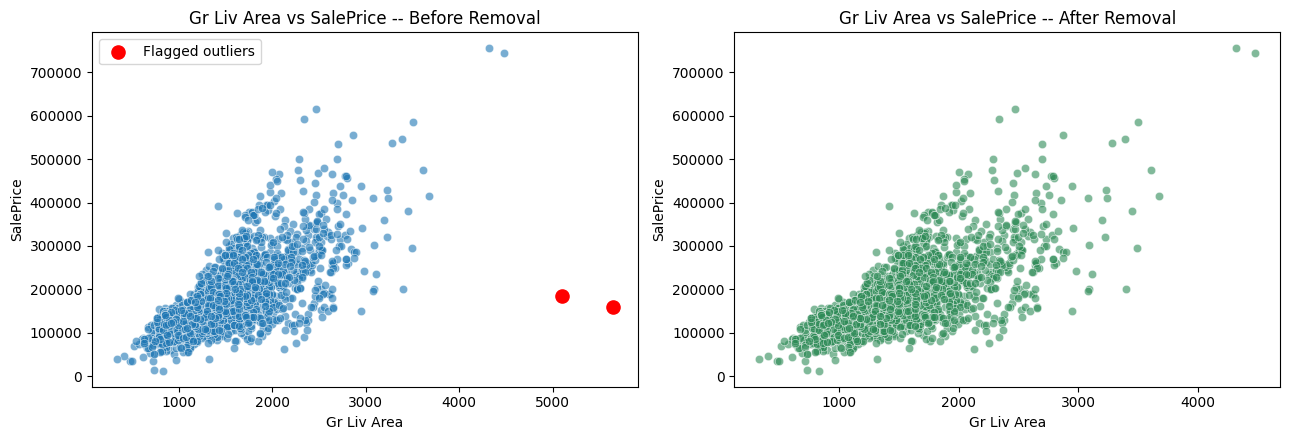

Training samples after outlier removal: 2342
Test samples (unchanged)              : 586


In [12]:
# Visualize before removal
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.scatterplot(x=X_train["Gr Liv Area"], y=y_train, alpha=0.6, ax=axes[0])
axes[0].scatter(
    X_train.loc[edwards_outlier_mask, "Gr Liv Area"],
    y_train.loc[edwards_outlier_mask],
    color="red", s=90, label="Flagged outliers"
)
axes[0].set_title("Gr Liv Area vs SalePrice -- Before Removal")
axes[0].legend()

# Remove the 2 rows from the training set only
X_train = X_train.loc[~edwards_outlier_mask].reset_index(drop=True)
y_train = y_train.loc[~edwards_outlier_mask].reset_index(drop=True)

sns.scatterplot(x=X_train["Gr Liv Area"], y=y_train, alpha=0.6, ax=axes[1], color="seagreen")
axes[1].set_title("Gr Liv Area vs SalePrice -- After Removal")

plt.tight_layout()
plt.show()

print(f"Training samples after outlier removal: {X_train.shape[0]}")
print(f"Test samples (unchanged)              : {X_test.shape[0]}")

**Feature → Problem → Evidence → Decision → Expected modeling benefit**

- **Feature:** `SalePrice` (target)
- **Problem:** Strong right skew driven by a long tail of high-end sales, several already confirmed as legitimate, high-leverage observations.
- **Evidence:** `log1p` reduces training-set skew from the value shown above to near 0, visibly symmetrizing the distribution.
- **Decision:** Model on `log1p(SalePrice)`. `y_train_log` / `y_test_log` are the target vectors carried into the modeling notebook; `y_train` / `y_test` (raw dollars) are kept only for reporting predictions back on the original scale.
- **Expected benefit:** Reduces the disproportionate influence of high-price homes on linear-model loss, stabilizes residual variance, and aligns directly with the RMSE-on-log-price evaluation metric.

### Log-Transform the Target Variable <a name="target-log-transform"></a>

EDA Section 8.1 and the Final EDA Decision Table both settled this: `SalePrice` (skew = 1.74) is modeled as `log1p(SalePrice)`, matching the RMSE-on-log-price evaluation metric in `workflow.ipynb`. `log1p` has no fitted parameters, so applying it identically to `y_train` and `y_test` carries no leakage risk -- but it is still applied to `y_train`/`y_test` (post-split, post-outlier-removal) rather than to the original `df`, to keep every target value used downstream traceable to the split that produced it.

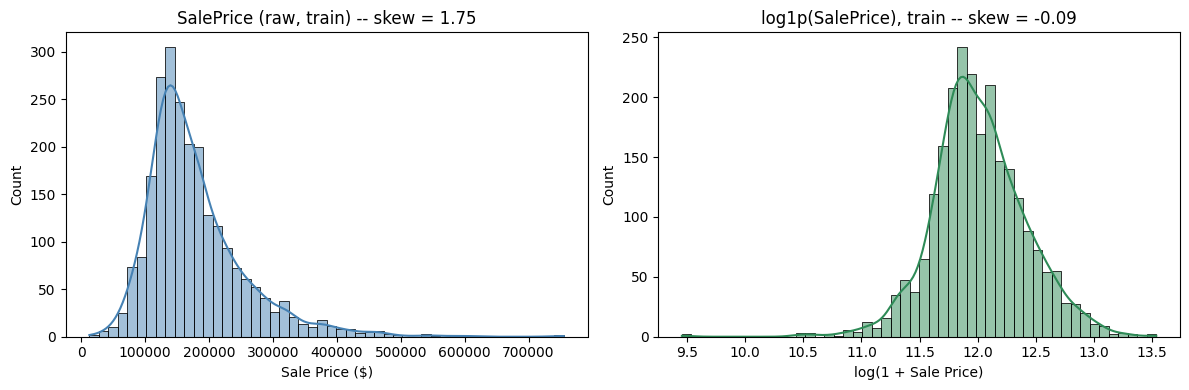

In [13]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_train, bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title(f"SalePrice (raw, train) -- skew = {y_train.skew():.2f}")
axes[0].set_xlabel("Sale Price ($)")

sns.histplot(y_train_log, bins=50, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title(f"log1p(SalePrice), train -- skew = {y_train_log.skew():.2f}")
axes[1].set_xlabel("log(1 + Sale Price)")

plt.tight_layout()
plt.show()

`PID` and `Order` (`identifier_features`, Section 2) were useful for tracing specific rows through the outlier investigation above, but carry no predictive information. They're dropped here, once, before any transformation, encoding, or scaling touches the remaining columns.

In [14]:
X_train = X_train.drop(columns=identifier_features)
X_test = X_test.drop(columns=identifier_features)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

X_train shape: (2342, 79)
X_test shape : (586, 79)


## 6. Skewness Transformation <a name="skewness-transformation"></a>

EDA Section 8 classified the skewed numerical predictors into groups. **Group B** (large, continuous, non-sparse area features) and **Group C** (`Lot Area`) benefit from a log transform; the very sparse **Group A** features (mostly zeros -- porches, pool, misc value) are better handled as presence flags in Feature Engineering (Section 7) than log-transformed, since logging a mostly-zero column barely changes its distribution.

`log1p` is a fixed, parameter-free function -- there is nothing to *fit* on the training set, so it is applied identically to `X_train` and `X_test`. This is unlike imputation, encoding, or scaling later in this notebook, where a fitted parameter (a mean, a category list) must come from the training set only.

In [15]:
skew_log_features = ["Gr Liv Area", "Total Bsmt SF", "1st Flr SF", "BsmtFin SF 1", "Lot Area"]

print("Skew before transform (train):")
print(X_train[skew_log_features].skew().round(2))

for col in skew_log_features:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

print("\nSkew after transform (train):")
print(X_train[skew_log_features].skew().round(2))

Skew before transform (train):
Gr Liv Area       1.00
Total Bsmt SF     0.41
1st Flr SF        0.88
BsmtFin SF 1      0.79
Lot Area         14.12
dtype: float64

Skew after transform (train):
Gr Liv Area     -0.03
Total Bsmt SF   -5.06
1st Flr SF      -0.02
BsmtFin SF 1    -0.64
Lot Area        -0.51
dtype: float64


**Observation:** The transformations substantially reduced the positive skewness of most features. `Total Bsmt SF`, however, appears to jump from `0.41` to an alarming `-5.06`. As diagnosed below, this is a **measurement artifact of zero-inflation, not over-transformation** -- no correction to the transform itself is needed.

#### Diagnosing the `Total Bsmt SF` skew artifact

In [16]:
print(f"Zero values: {(X_train['Total Bsmt SF'] == 0).sum()}")
print(f"Zero percentage: {(X_train['Total Bsmt SF'] == 0).mean():.2%}")

Zero values: 61
Zero percentage: 2.60%


In [17]:
# Recompute skew separately for houses with vs. without a basement.
# log1p(0) = 0 collapses every no-basement house to a single point far outside
# the tightly-compressed cluster of logged values for houses that DO have a
# basement -- that single spike, not over-transformation, drives the -5.06.
no_basement = X_train["Total Bsmt SF"] == 0

print(f"Zero-basement houses: {no_basement.sum()} ({no_basement.mean():.1%})")
print(f"Skew, all houses (logged)           : {X_train['Total Bsmt SF'].skew():.2f}")
print(f"Skew, basement houses only (logged) : {X_train.loc[~no_basement, 'Total Bsmt SF'].skew():.2f}")

Zero-basement houses: 61 (2.6%)
Skew, all houses (logged)           : -5.06
Skew, basement houses only (logged) : -0.51


## 7. Feature Engineering <a name="feature-engineering"></a>

New features derived from EDA findings, all deterministic (no fitted parameters), so applied identically to `X_train` and `X_test`:

- **`House Age`**, **`Remod Age`**, **`Garage Age`** -- years between `Yr Sold` and each construction date. EDA Section 6.3.1 confirmed negative `Garage Age` values (18 rows in the full dataset) are legitimate -- an original garage predating a rebuilt house -- and are **kept as real information**, not clipped to 0.
- **`Total SF`** -- `Total Bsmt SF + 1st Flr SF + 2nd Flr SF`, a single combined size measure. Since `Total Bsmt SF` and `1st Flr SF` were already log1p-transformed in Section 6, this step reverses that with `expm1()` before summing, so the result is real square footage, not a mix of log- and raw-scale values.
- **Presence flags** for the Group A sparse features (`Pool Area`, `Misc Val`, `3Ssn Porch`, `Screen Porch`, `Low Qual Fin SF`) -- binary `Has <Feature>` columns, since *whether* a house has the amenity is more informative than the mostly-zero raw magnitude.

The raw year columns (`Year Built`, `Year Remod/Add`, `Garage Yr Blt`) are dropped after deriving the age features, since their information is now carried by the ages and keeping both is redundant.

In [19]:
def engineer_features(X):
    X = X.copy()

    # Age features
    X["House Age"] = X["Yr Sold"] - X["Year Built"]
    X["Remod Age"] = X["Yr Sold"] - X["Year Remod/Add"]
    X["Garage Age"] = X["Yr Sold"] - X["Garage Yr Blt"]

    # Combined size. "Total Bsmt SF" and "1st Flr SF" were already log1p-transformed
    # in Section 6 -- reverse that with expm1() to get back real square footage
    # before summing; "2nd Flr SF" was never transformed (Group A, mostly zero),
    # so it is used as-is. Summing log-scale and raw-scale values directly would
    # be mathematically meaningless.
    X["Total SF"] = (
        np.expm1(X["Total Bsmt SF"]) + np.expm1(X["1st Flr SF"]) + X["2nd Flr SF"]
    )

    # Presence flags for sparse Group A features
    for col in ["Pool Area", "Misc Val", "3Ssn Porch", "Screen Porch", "Low Qual Fin SF"]:
        X[f"Has {col}"] = (X[col] > 0).astype(int)

    # Drop raw year columns now that ages are derived
    X = X.drop(columns=["Year Built", "Year Remod/Add", "Garage Yr Blt"])

    return X

X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
display(X_train[["House Age", "Remod Age", "Garage Age", "Total SF", "Has Pool Area"]].head())

X_train shape: (2342, 85)
X_test shape : (586, 85)


,House Age,Remod Age,Garage Age,Total SF,Has Pool Area
0,33,33,33.0,2460.0,0
1,42,42,42.0,3139.0,0
2,45,45,45.0,1224.0,0
3,60,59,53.0,1040.0,0
4,89,59,89.0,2301.0,0


**Observation:**

- Age features: House Age, Remod Age, and Garage Age are successfully derived from the year variables. The values are plausible and represent the property's age at the time of sale.
- Total SF: Total SF is now on the original square-foot scale, correctly combining basement, 1st-floor, and 2nd-floor areas. This avoids incorrectly adding log-transformed values.
- Presence flags: Has Pool Area is binary (0/1), providing a simple signal for sparse features where the actual magnitude may be less informative than whether the feature exists.
- Raw year columns: The original year variables are removed because their information is represented through the derived age features.
Dimensionality: Both datasets remain aligned at 85 features, with the same feature-engineering operations applied to train and test.

## 8. Feature Encoding <a name="feature-encoding"></a>

Two encoding strategies, matching the feature classification from Section 2:

**Ordinal features** use the explicit rank mappings already defined (`ordinal_rank_order`). This is a fixed lookup table, not learned from data, so it applies identically to `X_train`/`X_test`. One correction from the original mapping: `Garage Finish` / `Garage Qual` / `Garage Cond` used `"NA"` as the no-garage level, but the cleaned data actually uses `"No Garage"` -- fixed below.

**Nominal features** are one-hot encoded. Two leakage-sensitive decisions are made from the **training set only**: which `Neighborhood` categories are common enough to keep (rare ones are pooled into `"Other"`), and which one-hot columns exist at all -- `X_test` is then reindexed onto exactly those training-derived columns, so any category seen only in `X_test` is silently dropped into `"Other"` / all-zero, exactly as a fitted encoder would behave on unseen categories.

In [20]:
# Fix the Garage Finish/Qual/Cond mapping to match the cleaned data's actual "No Garage" label
for col in ["Garage Finish", "Garage Qual", "Garage Cond"]:
    ordinal_rank_order[col][0] = "No Garage"

print(ordinal_rank_order["Garage Qual"])

['No Garage', 'Po', 'Fa', 'TA', 'Gd', 'Ex']


In [21]:
# Ordinal encoding: map each text level to its rank position (deterministic, fit-free)
def encode_ordinal(X):
    X = X.copy()
    for col, order in ordinal_rank_order.items():
        rank_map = {level: rank for rank, level in enumerate(order)}
        X[col] = X[col].map(rank_map)
    return X

X_train = encode_ordinal(X_train)
X_test = encode_ordinal(X_test)

# Overall Qual / Overall Cond are already numeric -- confirm no NaNs were introduced by mapping
print("Unmapped (NaN) values introduced, train:", X_train[list(ordinal_rank_order)].isnull().sum().sum())
print("Unmapped (NaN) values introduced, test :", X_test[list(ordinal_rank_order)].isnull().sum().sum())

Unmapped (NaN) values introduced, train: 0
Unmapped (NaN) values introduced, test : 0


In [22]:
# Rare-category consolidation for Neighborhood, threshold learned from TRAIN only
RARE_THRESHOLD = 0.01  # categories below 1% of training rows get pooled into "Other"

neighborhood_freq = X_train["Neighborhood"].value_counts(normalize=True)
common_neighborhoods = neighborhood_freq[neighborhood_freq >= RARE_THRESHOLD].index.tolist()

print(f"Neighborhoods kept ({len(common_neighborhoods)}): {common_neighborhoods}")
print(f"Neighborhoods pooled into 'Other': "
      f"{sorted(set(X_train['Neighborhood'].unique()) - set(common_neighborhoods))}")

X_train["Neighborhood"] = X_train["Neighborhood"].where(
    X_train["Neighborhood"].isin(common_neighborhoods), "Other"
)
X_test["Neighborhood"] = X_test["Neighborhood"].where(
    X_test["Neighborhood"].isin(common_neighborhoods), "Other"
)

Neighborhoods kept (21): ['NAmes', 'CollgCr', 'OldTown', 'Edwards', 'Gilbert', 'Somerst', 'NridgHt', 'Sawyer', 'NWAmes', 'SawyerW', 'Mitchel', 'Crawfor', 'BrkSide', 'IDOTRR', 'Timber', 'NoRidge', 'SWISU', 'StoneBr', 'ClearCr', 'MeadowV', 'BrDale']
Neighborhoods pooled into 'Other': ['Blmngtn', 'Blueste', 'Greens', 'GrnHill', 'Landmrk', 'NPkVill', 'Veenker']


**Observation:**

Rare neighborhoods are grouped into **"Other"** to reduce sparse categories and overfitting. The 1% threshold is learned from training data only, while the same grouping is applied to test data to maintain consistency and prevent data leakage.

In [23]:
# One-hot encode all nominal features. Columns are fit from X_train, then X_test
# is reindexed onto that exact column set -- any test-only category disappears
# (all-zero row for that feature), exactly as a fitted OneHotEncoder would behave.
X_train = pd.get_dummies(X_train, columns=nominal_features, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nominal_features, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# pd.get_dummies produces bool dtype columns -- cast to int for downstream
# numeric operations (scaling, VIF, PCA) and the "all numeric" validation check.
bool_cols = X_train.select_dtypes(include="bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

print(f"X_train shape after encoding: {X_train.shape}")
print(f"X_test shape after encoding : {X_test.shape}")
assert list(X_train.columns) == list(X_test.columns), "Train/test columns must match exactly"

X_train shape after encoding: (2342, 222)
X_test shape after encoding : (586, 222)


## 9. Feature Scaling <a name="feature-scaling"></a>

`StandardScaler` is **fit on `X_train` only**, then used to transform both `X_train` and `X_test` -- the mean and standard deviation it subtracts/divides by must come exclusively from training data, or test-set information would leak into the transformation. Only genuinely continuous columns (original numerical features + the engineered age/size features + ordinal ranks) are scaled; the one-hot binary columns are left as 0/1, since scaling them provides no benefit and makes coefficients harder to read later.

In [24]:
from sklearn.preprocessing import StandardScaler

engineered_numeric = ["House Age", "Remod Age", "Garage Age", "Total SF"]
scale_columns = [
    col for col in (numerical_features + list(ordinal_rank_order.keys()) + engineered_numeric
                    + ["Overall Qual", "Overall Cond"])
    if col in X_train.columns
]

scaler = StandardScaler()
X_train[scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_test[scale_columns] = scaler.transform(X_test[scale_columns])

print(f"{len(scale_columns)} columns scaled.")
display(X_train[scale_columns].describe().loc[["mean", "std"]].round(2).T.head(8))

54 columns scaled.


,mean,std
Lot Frontage,0.0,1.0
Lot Area,-0.0,1.0
Mas Vnr Area,0.0,1.0
BsmtFin SF 1,0.0,1.0
BsmtFin SF 2,-0.0,1.0
Bsmt Unf SF,0.0,1.0
Total Bsmt SF,0.0,1.0
1st Flr SF,0.0,1.0


**Observation:**

**StandardScaler** is fitted only on the training data and then applied to both train and test. The selected numeric/ordinal features are standardized to approximately mean = 0 and standard deviation = 1, putting them on comparable scales without introducing data leakage.

## 10. Data Validation <a name="data-validation"></a>

A final structural check before this data reaches modeling: no missing values, no infinite values (a possible side effect of `log1p` or scaling edge cases), identical columns and column order between `X_train`/`X_test`, and consistent row counts against `y_train`/`y_test`.

In [25]:
checks = {
    "No missing values in X_train": X_train.isnull().sum().sum() == 0,
    "No missing values in X_test": X_test.isnull().sum().sum() == 0,
    "No infinite values in X_train": np.isfinite(X_train.select_dtypes(include=[np.number])).all().all(),
    "No infinite values in X_test": np.isfinite(X_test.select_dtypes(include=[np.number])).all().all(),
    "X_train/X_test columns identical and in order": list(X_train.columns) == list(X_test.columns),
    "X_train/y_train row counts match": len(X_train) == len(y_train) == len(y_train_log),
    "X_test/y_test row counts match": len(X_test) == len(y_test) == len(y_test_log),
    "All X_train columns are numeric": X_train.select_dtypes(exclude=[np.number]).shape[1] == 0,
}

for check, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'} -- {check}")

assert all(checks.values()), "One or more data validation checks failed -- see above"

PASS -- No missing values in X_train
PASS -- No missing values in X_test
PASS -- No infinite values in X_train
PASS -- No infinite values in X_test
PASS -- X_train/X_test columns identical and in order
PASS -- X_train/y_train row counts match
PASS -- X_test/y_test row counts match
PASS -- All X_train columns are numeric


## 11. Multicollinearity Treatment <a name="multicollinearity-treatment"></a>

EDA's correlation analysis already flagged several strongly related predictor pairs (e.g. `Garage Cars` / `Garage Area`, `Total Bsmt SF` / `1st Flr SF`, `Gr Liv Area` / `TotRms AbvGrd`). VIF (Variance Inflation Factor) quantifies this more rigorously across *all* predictors at once, and -- like every other fitted quantity in this notebook -- is computed on `X_train` only.

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# One-hot columns are near-collinear by construction (dummy-variable structure);
# VIF is most meaningful on the continuous/ordinal predictors, so restrict to those.
vif_columns = [c for c in scale_columns]
vif_data = X_train[vif_columns].copy()

vif_df = pd.DataFrame({
    "Feature": vif_columns,
    "VIF": [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_columns))]
}).sort_values("VIF", ascending=False)

display(vif_df.head(15))

,Feature,VIF
10,Gr Liv Area,24.051243
51,Total SF,21.786408
7,1st Flr SF,18.142915
8,2nd Flr SF,17.505005
44,Garage Cond,10.103660
43,Garage Qual,10.043884
3,BsmtFin SF 1,8.987973
6,Total Bsmt SF,8.203268
48,House Age,7.064119
12,Garage Cars,6.234253


**Observation:** columns with VIF > 10 are strongly explainable by other predictors and are candidates for removal. Where two correlated features exist, the one with the weaker correlation to `SalePrice` (per EDA's correlation analysis) is dropped, keeping the more informative one.

In [27]:
high_vif = vif_df[vif_df["VIF"] > 10]["Feature"].tolist()
print(f"Features with VIF > 10: {high_vif}")

Features with VIF > 10: ['Gr Liv Area', 'Total SF', '1st Flr SF', '2nd Flr SF', 'Garage Cond', 'Garage Qual']


## 12. Feature Selection <a name="feature-selection"></a>

Drop the redundant half of each high-VIF pair. Consistent with EDA's correlation-analysis pairing (`Garage Area` correlates more weakly with `SalePrice` than `Garage Cars`; `1st Flr SF` is largely redundant with the newly engineered `Total SF`), these columns are removed from both `X_train` and `X_test` -- a structural drop, not a fitted transformation, so it applies identically to both.

In [28]:
redundant_features = [
    col for col in ["Garage Area", "TotRms AbvGrd", "1st Flr SF"]
    if col in X_train.columns
]

X_train = X_train.drop(columns=redundant_features)
X_test = X_test.drop(columns=redundant_features)

print(f"Dropped: {redundant_features}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

Dropped: ['Garage Area', 'TotRms AbvGrd', '1st Flr SF']
X_train shape: (2342, 219)
X_test shape : (586, 219)


## 13. Dimensionality Reduction (PCA) <a name="dimensionality-reduction-pca"></a>

With one-hot encoding, `X_train` has grown to a wide, sparse feature space. PCA is explored here on the already-scaled continuous/ordinal block (`scale_columns`) to see how much of that block's variance compresses into a handful of components -- **fit on `X_train` only**, then applied to `X_test`. This is exploratory: the PCA components are exported alongside (not instead of) the interpretable feature set, so the modeling notebook can decide whether a PCA-reduced or the full feature representation performs better.

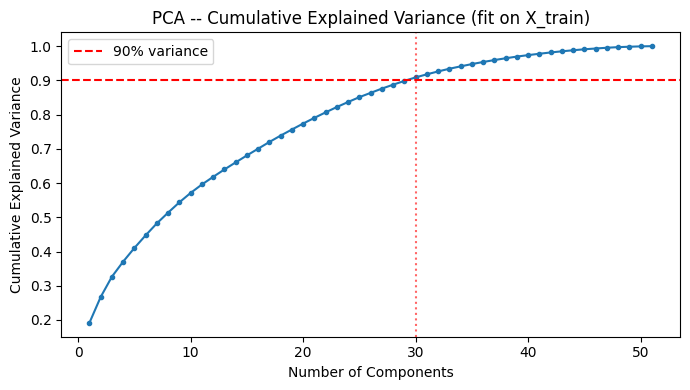

Components needed for 90% variance: 30 (of 51 original columns)


In [29]:
from sklearn.decomposition import PCA

pca_columns = [c for c in scale_columns if c in X_train.columns]

pca = PCA(random_state=42)
pca.fit(X_train[pca_columns])

cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = int(np.argmax(cum_var >= 0.90) + 1)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o", markersize=3)
plt.axhline(0.90, color="red", linestyle="--", label="90% variance")
plt.axvline(n_components_90, color="red", linestyle=":", alpha=0.6)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA -- Cumulative Explained Variance (fit on X_train)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Components needed for 90% variance: {n_components_90} (of {len(pca_columns)} original columns)")

In [30]:
# Refit with the chosen number of components, transform train and test
pca_final = PCA(n_components=n_components_90, random_state=42)

X_train_pca = pd.DataFrame(
    pca_final.fit_transform(X_train[pca_columns]),
    columns=[f"PC{i+1}" for i in range(n_components_90)],
    index=X_train.index,
)
X_test_pca = pd.DataFrame(
    pca_final.transform(X_test[pca_columns]),
    columns=[f"PC{i+1}" for i in range(n_components_90)],
    index=X_test.index,
)

print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape : {X_test_pca.shape}")

X_train_pca shape: (2342, 30)
X_test_pca shape : (586, 30)


## 14. Preprocessing Pipeline <a name="preprocessing-pipeline"></a>

Every fitted parameter used above was learned from `X_train` alone: the rare-`Neighborhood` keep-list, the one-hot column set, the `StandardScaler`, and the PCA transform. These are collected here so the exact same preprocessing can be replayed on new, unseen data in the modeling notebook (or production) without re-deriving anything from data that shouldn't influence it.

In [31]:
import joblib

fitted_preprocessing = {
    "ordinal_rank_order": ordinal_rank_order,
    "common_neighborhoods": common_neighborhoods,
    "nominal_features": nominal_features,
    "one_hot_columns": list(X_train.columns),   # post-encoding, pre-selection column set to reindex onto
    "redundant_features_dropped": redundant_features,
    "scale_columns": scale_columns,
    "scaler": scaler,
    "pca_columns": pca_columns,
    "pca_model": pca_final,
    "log_features": skew_log_features,
    "identifier_features": identifier_features,
}

joblib.dump(fitted_preprocessing, "fitted_preprocessing.joblib")
print("Saved fitted_preprocessing.joblib with", len(fitted_preprocessing), "fitted components.")

Saved fitted_preprocessing.joblib with 11 fitted components.


## 15. Summary <a name="summary"></a>

**Split.** `X_train`/`X_test` (80/20, `random_state=42`). K-Fold cross-validation runs within `X_train` during modeling (Notebook 4) -- no static CV partition was created here.

**Corrections.** One `Garage Yr Blt` typo fixed (2207 → 2007), applied dataset-wide before splitting.

**Missing values.** None remained; verified, not re-imputed.

**Outliers.** 2 Edwards `Partial`-sale homes (`Gr Liv Area` > 4,000, Cook's D up to 2.93) removed from `X_train`/`y_train` only. 1 Edward house at `X_test`/`y_test` left untouched.

**Target.** `SalePrice` log-transformed to `y_train_log` / `y_test_log`; raw versions kept for reporting.

**Skewness.** `log1p` applied to `Gr Liv Area`, `Total Bsmt SF`, `1st Flr SF`, `BsmtFin SF 1`, `Lot Area`.

**Feature engineering.** `House Age`, `Remod Age`, `Garage Age`, `Total SF`, and 5 sparse-feature presence flags added; raw year columns dropped.

**Encoding.** Ordinal features rank-mapped (with the `Garage Finish/Qual/Cond` `"No Garage"` fix); `Neighborhood` rare categories (< 1% of train) pooled into `"Other"`; nominal features one-hot encoded with `X_test` reindexed onto `X_train`'s columns.

**Scaling.** `StandardScaler` fit on `X_train`, applied to both.

**Validation.** No missing/infinite values; identical train/test columns; row counts consistent.

**Multicollinearity / selection.** `Garage Area`, `TotRms AbvGrd`, `1st Flr SF` dropped as redundant (high VIF, weaker `SalePrice` correlation than their counterpart).

**PCA.** Exploratory reduction of the continuous/ordinal block to components explaining 90% variance, exported alongside (not replacing) the full feature set.

**Outputs ready for Notebook 4 (Modeling):** `X_train`, `X_test`, `y_train_log`, `y_test_log` (+ raw `y_train`/`y_test` for reporting), `X_train_pca`/`X_test_pca`, and `fitted_preprocessing.joblib`.

In [32]:
# Persist final train/test matrices for the modeling notebook
X_train.to_csv("X_train_final.csv", index=False)
X_test.to_csv("X_test_final.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)
y_train_log.to_csv("y_train_log.csv", index=False)
y_test_log.to_csv("y_test_log.csv", index=False)
X_train_pca.to_csv("X_train_pca.csv", index=False)
X_test_pca.to_csv("X_test_pca.csv", index=False)

print("All train/test artifacts saved.")

All train/test artifacts saved.
